# Final Full-Dataset Single-Class Periapical Lesion Detection

**Objective:** Evaluate YOLO11m for periapical lesion detection and localization using the full dataset after merging all severity labels into one class: `periapical_lesion`.

**Rationale:** The original Type3, Type4, and Type5 labels were merged to assess lesion localization performance without excluding any images or annotations.


## 1. Install and Import Dependencies

In [4]:
!pip -q install ultralytics pyyaml opencv-python-headless

In [5]:
import os, gc, json, random, shutil, subprocess, time
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import yaml
import cv2
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import torch
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Configuration

The dataset is expected in Google Drive at:

`/content/drive/MyDrive/G_B/dataset`

Expected structure:

```text
dataset/
  images/
    train/
    val/
    test/
  labels/
    train/
    val/
    test/
  data.yaml
```


In [6]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# === Input dataset on Google Drive ===
DATASET_DRIVE = Path("/content/drive/MyDrive/G_B/dataset")

# === Local runtime copy for faster training ===
RAW_DATA_DIR = Path("/content/periapical_raw")
YOLO_DATA_DIR = Path("/content/periapical_single_class")

# === Output directly to Drive so results are not lost if Colab stops ===
DRIVE_OUTPUT_DIR = Path("/content/drive/MyDrive/periapical_final_single_class_45ep")

# === Training settings ===
MODEL_NAME = "yolo11m.pt"        # Good balance; previous run was promising with this model.
EPOCHS = 45                     # 100 is unnecessary; previous peak appeared around epoch 41-42.
PATIENCE = 8
IMG_SIZE = 1024
BATCH = 8                       # If CUDA out of memory: change to 4.
WORKERS = 2
SAVE_PERIOD = 1                 # Save every epoch to Drive.

# === Evaluation settings ===
CONF_THRESHOLD = 0.25           # Clinical prediction/error analysis threshold.
IOU_THRESHOLD = 0.50

RUN_NAME = f"single_class_yolo11m_45ep_1024_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

print("DATASET_DRIVE:", DATASET_DRIVE)
print("RAW_DATA_DIR:", RAW_DATA_DIR)
print("YOLO_DATA_DIR:", YOLO_DATA_DIR)
print("DRIVE_OUTPUT_DIR:", DRIVE_OUTPUT_DIR)
print("RUN_NAME:", RUN_NAME)

assert DATASET_DRIVE.exists(), f"Dataset folder not found: {DATASET_DRIVE}"
DRIVE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive
DATASET_DRIVE: /content/drive/MyDrive/G_B/dataset
RAW_DATA_DIR: /content/periapical_raw
YOLO_DATA_DIR: /content/periapical_single_class
DRIVE_OUTPUT_DIR: /content/drive/MyDrive/periapical_final_single_class_45ep
RUN_NAME: single_class_yolo11m_45ep_1024_20260522_213137


## 3. Check Dataset on Drive

This cell confirms that the Drive shortcut/path is correct before copying anything.

In [7]:
print("Top-level items inside dataset:")
for item in sorted(DATASET_DRIVE.iterdir()):
    print("-", item.name)

drive_images = list((DATASET_DRIVE / "images").rglob("*"))
drive_labels = list((DATASET_DRIVE / "labels").rglob("*.txt"))

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
drive_image_files = [p for p in drive_images if p.is_file() and p.suffix.lower() in image_exts]

print("\nDrive images count:", len(drive_image_files))
print("Drive labels count:", len(drive_labels))

assert len(drive_image_files) > 0, "No images found under dataset/images"
assert len(drive_labels) > 0, "No label txt files found under dataset/labels"
assert (DATASET_DRIVE / "data.yaml").exists(), "data.yaml not found"

Top-level items inside dataset:
- data.yaml
- images
- label
- labels

Drive images count: 3924
Drive labels count: 3924


## 4. Copy Required Data to Local Runtime

Only the required dataset components are copied:
- `images`
- `labels`
- `data.yaml`


In [8]:
# Clean incomplete previous local copies only.
if RAW_DATA_DIR.exists():
    print("Removing old local raw copy:", RAW_DATA_DIR)
    shutil.rmtree(RAW_DATA_DIR)

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)

def rsync_folder(src, dst):
    src = str(src).rstrip("/") + "/"
    dst = str(dst).rstrip("/") + "/"
    Path(dst).mkdir(parents=True, exist_ok=True)
    cmd = ["rsync", "-ah", "--info=progress2", src, dst]
    print("Running:", " ".join(cmd))
    result = subprocess.run(cmd, text=True)
    if result.returncode != 0:
        raise RuntimeError(f"rsync failed: {src} -> {dst}")

rsync_folder(DATASET_DRIVE / "images", RAW_DATA_DIR / "images")
rsync_folder(DATASET_DRIVE / "labels", RAW_DATA_DIR / "labels")
shutil.copy2(DATASET_DRIVE / "data.yaml", RAW_DATA_DIR / "data.yaml")

local_images = [p for p in (RAW_DATA_DIR / "images").rglob("*") if p.is_file() and p.suffix.lower() in image_exts]
local_labels = [p for p in (RAW_DATA_DIR / "labels").rglob("*.txt")]

print("\\nCopied images:", len(local_images))
print("Copied labels:", len(local_labels))
print("Raw folder items:", [p.name for p in RAW_DATA_DIR.iterdir()])

assert len(local_images) == len(drive_image_files), "Image count mismatch after copy"
assert len(local_labels) == len(drive_labels), "Label count mismatch after copy"

Running: rsync -ah --info=progress2 /content/drive/MyDrive/G_B/dataset/images/ /content/periapical_raw/images/
Running: rsync -ah --info=progress2 /content/drive/MyDrive/G_B/dataset/labels/ /content/periapical_raw/labels/
\nCopied images: 3924
Copied labels: 3924
Raw folder items: ['labels', 'data.yaml', 'images']


## 5. Inspect Splits and Label Format

The notebook preserves the existing train/val/test split.

In [9]:
def infer_split(path: Path):
    parts = [x.lower() for x in path.parts]
    if "train" in parts:
        return "train"
    if "valid" in parts:
        return "val"
    if "val" in parts:
        return "val"
    if "test" in parts:
        return "test"
    return "unknown"

all_images = sorted([p for p in (RAW_DATA_DIR / "images").rglob("*") if p.is_file() and p.suffix.lower() in image_exts])
all_labels = sorted([p for p in (RAW_DATA_DIR / "labels").rglob("*.txt")])

df_images = pd.DataFrame({
    "image_path": [str(p) for p in all_images],
    "stem": [p.stem for p in all_images],
    "split": [infer_split(p) for p in all_images],
})

df_labels = pd.DataFrame({
    "label_path": [str(p) for p in all_labels],
    "stem": [p.stem for p in all_labels],
    "label_split": [infer_split(p) for p in all_labels],
})

print("Images by split:")
print(df_images["split"].value_counts(dropna=False))

print("\nLabels by split:")
print(df_labels["label_split"].value_counts(dropna=False))

assert set(df_images["split"].unique()).issubset({"train", "val", "test"}), "Some images are not inside train/val/test folders"
assert all((df_images["split"] == s).sum() > 0 for s in ["train", "val", "test"]), "Missing one of train/val/test image splits"

Images by split:
split
train    2746
test      590
val       588
Name: count, dtype: int64

Labels by split:
label_split
train    2746
test      590
val       588
Name: count, dtype: int64


## 6. Match Images with Labels

This creates a clean table of usable image-label pairs.

In [10]:
# Match by split + stem to avoid accidental cross-split matching.
label_map = {}
for p in all_labels:
    label_map[(infer_split(p), p.stem)] = p

records = []
missing_labels = []

for img in all_images:
    split = infer_split(img)
    lbl = label_map.get((split, img.stem))
    if lbl is None:
        missing_labels.append(str(img))
        continue
    records.append({
        "image": str(img),
        "label": str(lbl),
        "split": split,
    })

df = pd.DataFrame(records)

print("Usable image-label pairs:", len(df))
print("Missing labels:", len(missing_labels))
print("\nUsable pairs by split:")
print(df["split"].value_counts())

assert len(df) > 0, "No usable records found. Check folder structure."
assert len(missing_labels) == 0, "Some images have no matching label files."

df.to_csv(DRIVE_OUTPUT_DIR / "usable_records_before_single_class_conversion.csv", index=False)

Usable image-label pairs: 3924
Missing labels: 0

Usable pairs by split:
split
train    2746
test      590
val       588
Name: count, dtype: int64


## 7. Build Single-Class YOLO Dataset

All original classes are merged into class `0 = periapical_lesion`.

Original label rows like:

```text
2 0.51 0.42 0.08 0.06
```

become:

```text
0 0.51 0.42 0.08 0.06
```

In [11]:
def safe_symlink_or_copy(src: Path, dst: Path):
    if dst.exists() or dst.is_symlink():
        dst.unlink()
    try:
        os.symlink(src, dst)
    except Exception:
        shutil.copy2(src, dst)

def convert_label_to_single_class(src_label: Path, dst_label: Path):
    valid_lines = []
    for raw in src_label.read_text(errors="ignore").strip().splitlines():
        parts = raw.strip().split()
        if len(parts) < 5:
            continue
        try:
            # Original class ignored; all boxes become class 0.
            x, y, w, h = [float(v) for v in parts[1:5]]
            # Basic sanity clamp. Skip invalid boxes.
            if not (0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1):
                continue
            valid_lines.append(f"0 {x:.6f} {y:.6f} {w:.6f} {h:.6f}")
        except Exception:
            continue
    dst_label.write_text("\n".join(valid_lines) + ("\n" if valid_lines else ""))
    return len(valid_lines)

if YOLO_DATA_DIR.exists():
    shutil.rmtree(YOLO_DATA_DIR)

for split in ["train", "val", "test"]:
    (YOLO_DATA_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DATA_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

conversion_rows = []
box_counter = Counter()

for row in tqdm(df.itertuples(index=False), total=len(df), desc="Building single-class dataset"):
    img = Path(row.image)
    lbl = Path(row.label)
    split = row.split

    out_img = YOLO_DATA_DIR / "images" / split / img.name
    out_lbl = YOLO_DATA_DIR / "labels" / split / f"{img.stem}.txt"

    safe_symlink_or_copy(img, out_img)
    n_boxes = convert_label_to_single_class(lbl, out_lbl)

    box_counter[split] += n_boxes
    conversion_rows.append({
        "split": split,
        "image": str(img),
        "original_label": str(lbl),
        "converted_label": str(out_lbl),
        "boxes": n_boxes,
    })

conversion_df = pd.DataFrame(conversion_rows)
conversion_df.to_csv(DRIVE_OUTPUT_DIR / "single_class_conversion_records.csv", index=False)

data_yaml = {
    "path": str(YOLO_DATA_DIR),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": 1,
    "names": ["periapical_lesion"],
}
with open(YOLO_DATA_DIR / "data.yaml", "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print("YOLO single-class dataset created:", YOLO_DATA_DIR)
print("Images by split:")
print(conversion_df["split"].value_counts())
print("\nBoxes by split:")
print(dict(box_counter))
print("\ndata.yaml:")
print((YOLO_DATA_DIR / "data.yaml").read_text())

Building single-class dataset:   0%|          | 0/3924 [00:00<?, ?it/s]

YOLO single-class dataset created: /content/periapical_single_class
Images by split:
split
train    2746
test      590
val       588
Name: count, dtype: int64

Boxes by split:
{'test': 1013, 'train': 4719, 'val': 1009}

data.yaml:
path: /content/periapical_single_class
train: images/train
val: images/val
test: images/test
nc: 1
names:
- periapical_lesion



## 8. Dataset Sanity Check

This step validates image counts, label counts, bounding-box format, and class consistency before model training.


In [12]:
def check_dataset(yolo_dir: Path):
    rows = []
    problems = []
    for split in ["train", "val", "test"]:
        img_dir = yolo_dir / "images" / split
        lbl_dir = yolo_dir / "labels" / split
        imgs = sorted([p for p in img_dir.iterdir() if p.suffix.lower() in image_exts])
        total_boxes = 0
        empty_labels = 0

        for img in imgs:
            lbl = lbl_dir / f"{img.stem}.txt"
            if not lbl.exists():
                problems.append(f"Missing label for {img}")
                continue

            lines = lbl.read_text().strip().splitlines()
            if len(lines) == 0:
                empty_labels += 1

            for line in lines:
                parts = line.split()
                if len(parts) != 5:
                    problems.append(f"Bad label length: {lbl} -> {line}")
                    continue
                cls = int(float(parts[0]))
                vals = [float(v) for v in parts[1:]]
                if cls != 0:
                    problems.append(f"Non-zero class found: {lbl} -> {line}")
                if not all(0 <= v <= 1 for v in vals):
                    problems.append(f"Coordinate outside [0,1]: {lbl} -> {line}")
                if vals[2] <= 0 or vals[3] <= 0:
                    problems.append(f"Invalid box size: {lbl} -> {line}")
                total_boxes += 1

        rows.append({
            "split": split,
            "images": len(imgs),
            "boxes": total_boxes,
            "empty_labels": empty_labels,
        })
    return pd.DataFrame(rows), problems

sanity_df, problems = check_dataset(YOLO_DATA_DIR)
display(sanity_df)
sanity_df.to_csv(DRIVE_OUTPUT_DIR / "dataset_sanity_summary.csv", index=False)

print("Problems:", len(problems))
for p in problems[:20]:
    print(p)

assert len(problems) == 0, "Fix dataset problems before training."
assert sanity_df["images"].sum() > 0, "No images in YOLO dataset."
assert sanity_df["boxes"].sum() > 0, "No boxes in YOLO dataset."

,split,images,boxes,empty_labels
0,train,2746,4719,0
1,val,588,1009,0
2,test,590,1013,0


Problems: 0


## 9. Visual Check of Labels

Check that the red boxes are over lesion areas before training.

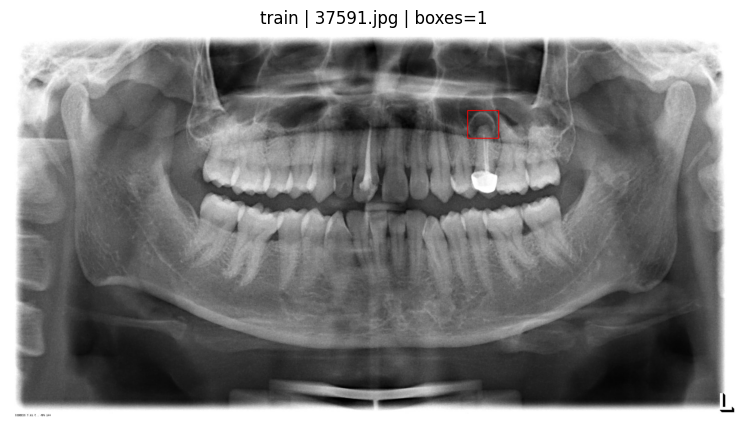

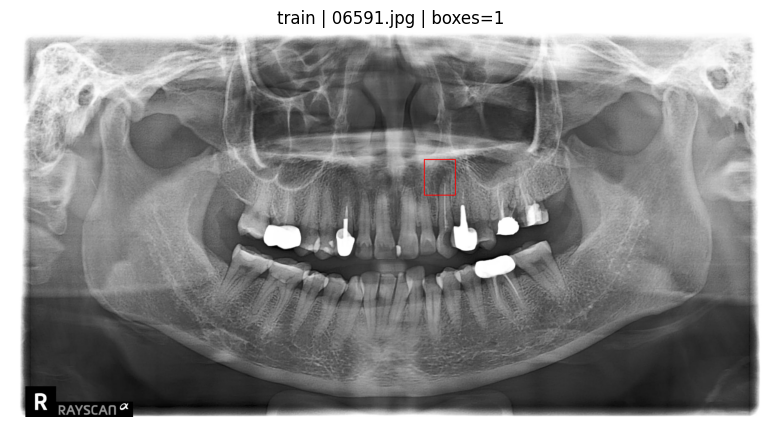

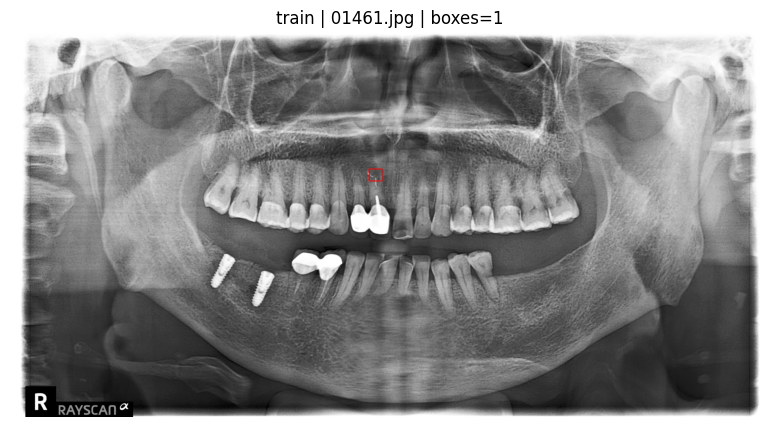

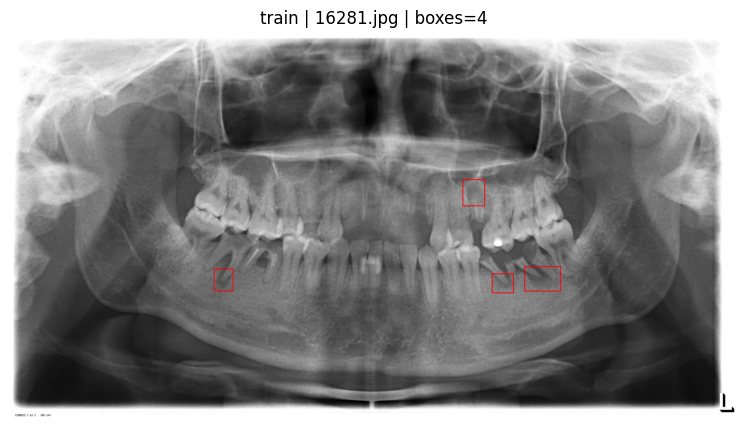

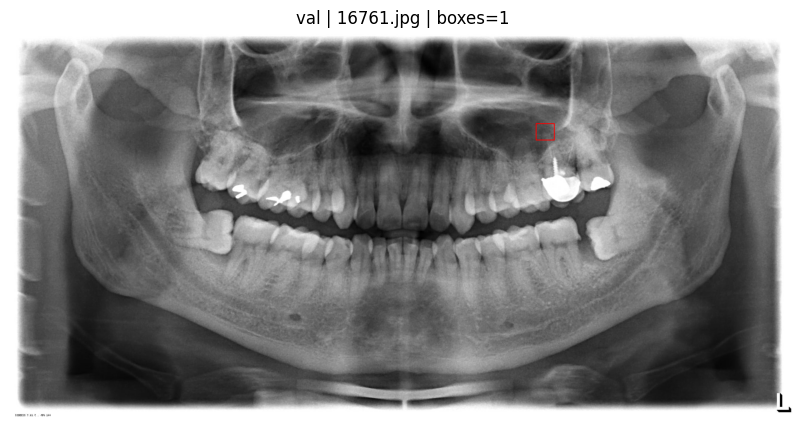

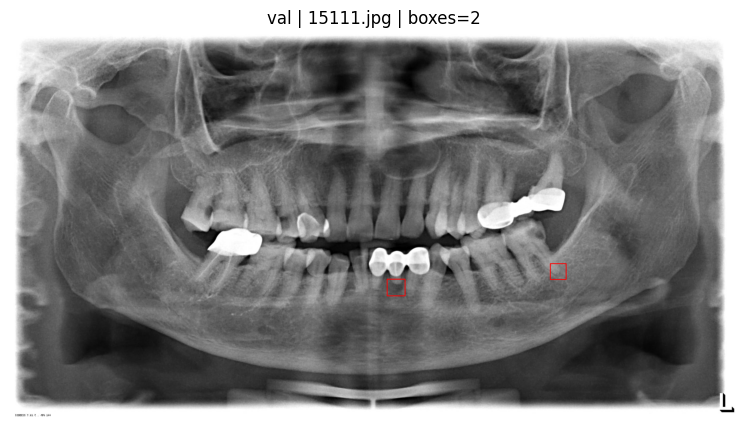

In [13]:
def show_labeled_samples(yolo_dir: Path, split="train", n=6):
    img_dir = yolo_dir / "images" / split
    lbl_dir = yolo_dir / "labels" / split
    imgs = sorted([p for p in img_dir.iterdir() if p.suffix.lower() in image_exts])
    sample = random.sample(imgs, min(n, len(imgs)))

    for img_path in sample:
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        lbl_path = lbl_dir / f"{img_path.stem}.txt"
        lines = lbl_path.read_text().strip().splitlines() if lbl_path.exists() else []

        for line in lines:
            _, x, y, bw, bh = map(float, line.split())
            x1 = int((x - bw / 2) * w)
            y1 = int((y - bh / 2) * h)
            x2 = int((x + bw / 2) * w)
            y2 = int((y + bh / 2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

        plt.figure(figsize=(12, 5))
        plt.imshow(img, cmap="gray")
        plt.title(f"{split} | {img_path.name} | boxes={len(lines)}")
        plt.axis("off")
        plt.show()

show_labeled_samples(YOLO_DATA_DIR, split="train", n=4)
show_labeled_samples(YOLO_DATA_DIR, split="val", n=2)

## 10. Train Final Model

YOLO11m is trained on the full dataset after converting all annotations to a single class. Training outputs are saved directly to Google Drive.


In [14]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

model = YOLO(MODEL_NAME)

train_results = model.train(
    data=str(YOLO_DATA_DIR / "data.yaml"),
    task="detect",
    epochs=EPOCHS,
    patience=PATIENCE,
    imgsz=IMG_SIZE,
    batch=BATCH,
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,
    cos_lr=True,
    pretrained=True,
    device=0 if torch.cuda.is_available() else "cpu",
    workers=WORKERS,
    project=str(DRIVE_OUTPUT_DIR),
    name=RUN_NAME,
    exist_ok=True,
    save=True,
    save_period=SAVE_PERIOD,
    seed=SEED,
    deterministic=True,
    amp=True,

    # X-ray-friendly augmentation
    hsv_h=0.0,
    hsv_s=0.05,
    hsv_v=0.25,
    degrees=5.0,
    translate=0.05,
    scale=0.20,
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=0.30,
    mixup=0.0,
    copy_paste=0.0,
    close_mosaic=10,

    # Extra safety: force single-class training.
    single_cls=True,
    verbose=True,
    plots=True,
)

RUN_DIR = Path(train_results.save_dir)
print("Training run saved to:", RUN_DIR)
print("best.pt:", RUN_DIR / "weights" / "best.pt")
print("last.pt:", RUN_DIR / "weights" / "last.pt")

assert (RUN_DIR / "weights" / "best.pt").exists(), "best.pt was not saved."

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/periapical_single_class/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=45, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.05, hsv_v=0.25, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=0.3, multi_scale=0.0, name=single_class_yolo11m_45ep_1024_20260522_213137, nbs=64, nms=False, opset=None, optimize=False

## 11. Official Validation and Test Evaluation

The final model is evaluated using standard object detection metrics:
- mAP50
- mAP50-95
- Precision
- Recall


In [16]:
best_model_path = RUN_DIR / "weights" / "best.pt"
assert best_model_path.exists(), f"best.pt not found: {best_model_path}"

best_model = YOLO(str(best_model_path))

val_metrics = best_model.val(
    data=str(YOLO_DATA_DIR / "data.yaml"),
    split="val",
    imgsz=IMG_SIZE,
    device=0 if torch.cuda.is_available() else "cpu",
    plots=True,
    save_json=True,
    project=str(DRIVE_OUTPUT_DIR),
    name="validation_best_model",
    exist_ok=True,
)

test_metrics = best_model.val(
    data=str(YOLO_DATA_DIR / "data.yaml"),
    split="test",
    imgsz=IMG_SIZE,
    device=0 if torch.cuda.is_available() else "cpu",
    plots=True,
    save_json=True,
    project=str(DRIVE_OUTPUT_DIR),
    name="test_best_model",
    exist_ok=True,
)

def metrics_to_dict(metrics, split):
    return {
        "split": split,
        "mAP50": float(metrics.box.map50),
        "mAP50_95": float(metrics.box.map),
        "Precision": float(metrics.box.mp),
        "Recall": float(metrics.box.mr),
    }

metrics_summary = pd.DataFrame([
    metrics_to_dict(val_metrics, "val"),
    metrics_to_dict(test_metrics, "test"),
])

display(metrics_summary)
metrics_summary.to_csv(DRIVE_OUTPUT_DIR / "single_class_metrics_summary.csv", index=False)
print("Saved:", DRIVE_OUTPUT_DIR / "single_class_metrics_summary.csv")

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2818.1±775.6 MB/s, size: 204.6 KB)
val: Scanning /content/periapical_single_class/labels/val.cache... 588 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 588/588 154.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 1.2it/s 31.3s
                   all        588       1009      0.715      0.668      0.727      0.334
Speed: 2.9ms preprocess, 41.3ms inference, 0.0ms loss, 1.2ms postprocess per image
Saving /content/drive/MyDrive/periapical_final_single_class_45ep/validation_best_model/predictions.json...
Results saved to /content/drive/MyDrive/periapical_final_single_class_45ep/validation_best_model
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast ima

,split,mAP50,mAP50_95,Precision,Recall
0,val,0.726546,0.333676,0.715396,0.667988
1,test,0.723781,0.330475,0.719323,0.646594


Saved: /content/drive/MyDrive/periapical_final_single_class_45ep/single_class_metrics_summary.csv


## 13. Manual Error Analysis at Confidence 0.25

This is for clinical-style interpretation:
- True positives
- False positives
- False negatives
- Image-level lesion detection

In [17]:
def load_gt_boxes_norm(label_path: Path):
    boxes = []
    if not label_path.exists():
        return np.zeros((0, 4), dtype=float)
    for line in label_path.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) != 5:
            continue
        _, x, y, w, h = map(float, parts)
        boxes.append([x - w/2, y - h/2, x + w/2, y + h/2])
    return np.array(boxes, dtype=float)

def iou_matrix(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)), dtype=float)

    area_a = np.maximum(0, a[:,2] - a[:,0]) * np.maximum(0, a[:,3] - a[:,1])
    area_b = np.maximum(0, b[:,2] - b[:,0]) * np.maximum(0, b[:,3] - b[:,1])

    ix1 = np.maximum(a[:, None, 0], b[None, :, 0])
    iy1 = np.maximum(a[:, None, 1], b[None, :, 1])
    ix2 = np.minimum(a[:, None, 2], b[None, :, 2])
    iy2 = np.minimum(a[:, None, 3], b[None, :, 3])

    inter = np.maximum(0, ix2 - ix1) * np.maximum(0, iy2 - iy1)
    union = area_a[:, None] + area_b[None, :] - inter
    return np.divide(inter, union, out=np.zeros_like(inter), where=union > 0)

test_img_dir = YOLO_DATA_DIR / "images" / "test"
test_lbl_dir = YOLO_DATA_DIR / "labels" / "test"
test_imgs = sorted([p for p in test_img_dir.iterdir() if p.suffix.lower() in image_exts])

error_rows = []
total_tp = total_fp = total_fn = 0
image_level_hit = 0

for img_path in tqdm(test_imgs, desc="Manual error analysis"):
    gt = load_gt_boxes_norm(test_lbl_dir / f"{img_path.stem}.txt")

    preds = best_model.predict(
        source=str(img_path),
        imgsz=IMG_SIZE,
        conf=CONF_THRESHOLD,
        iou=IOU_THRESHOLD,
        verbose=False,
        device=0 if torch.cuda.is_available() else "cpu",
    )[0]

    if preds.boxes is None or len(preds.boxes) == 0:
        pred_boxes = np.zeros((0, 4), dtype=float)
        confs = np.array([], dtype=float)
    else:
        pred_boxes = preds.boxes.xyxyn.cpu().numpy()
        confs = preds.boxes.conf.cpu().numpy()

    matched_gt = set()
    matched_pred = set()

    ious = iou_matrix(pred_boxes, gt)
    if ious.size > 0:
        pairs = []
        for pi in range(ious.shape[0]):
            for gi in range(ious.shape[1]):
                if ious[pi, gi] >= IOU_THRESHOLD:
                    pairs.append((ious[pi, gi], pi, gi))
        pairs.sort(reverse=True, key=lambda x: x[0])

        for iou_val, pi, gi in pairs:
            if pi not in matched_pred and gi not in matched_gt:
                matched_pred.add(pi)
                matched_gt.add(gi)

    tp = len(matched_gt)
    fp = len(pred_boxes) - len(matched_pred)
    fn = len(gt) - len(matched_gt)

    total_tp += tp
    total_fp += fp
    total_fn += fn

    if len(gt) > 0 and tp > 0:
        image_level_hit += 1

    error_rows.append({
        "image": img_path.name,
        "gt_boxes": len(gt),
        "pred_boxes": len(pred_boxes),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "max_conf": float(confs.max()) if len(confs) else 0.0,
    })

error_df = pd.DataFrame(error_rows)
precision_manual = total_tp / (total_tp + total_fp) if (total_tp + total_fp) else 0
recall_manual = total_tp / (total_tp + total_fn) if (total_tp + total_fn) else 0
f1_manual = 2 * precision_manual * recall_manual / (precision_manual + recall_manual) if (precision_manual + recall_manual) else 0
image_level_recall = image_level_hit / len(test_imgs) if len(test_imgs) else 0

error_summary = pd.DataFrame([{
    "conf": CONF_THRESHOLD,
    "iou": IOU_THRESHOLD,
    "TP": total_tp,
    "FP": total_fp,
    "FN": total_fn,
    "Precision_manual": precision_manual,
    "Recall_manual": recall_manual,
    "F1_manual": f1_manual,
    "Image_level_recall": image_level_recall,
    "test_images": len(test_imgs),
}])

display(error_summary)
error_df.to_csv(DRIVE_OUTPUT_DIR / f"test_error_analysis_conf_{CONF_THRESHOLD}.csv", index=False)
error_summary.to_csv(DRIVE_OUTPUT_DIR / f"test_error_summary_conf_{CONF_THRESHOLD}.csv", index=False)

Manual error analysis:   0%|          | 0/590 [00:00<?, ?it/s]

,conf,iou,TP,FP,FN,Precision_manual,Recall_manual,F1_manual,Image_level_recall,test_images
0,0.25,0.5,675,252,338,0.728155,0.666338,0.695876,0.798305,590


## 14. Save Prediction Samples for the Report

In [18]:
sample_imgs = random.sample(test_imgs, min(30, len(test_imgs)))

_ = best_model.predict(
    source=[str(p) for p in sample_imgs],
    imgsz=IMG_SIZE,
    conf=CONF_THRESHOLD,
    iou=IOU_THRESHOLD,
    save=True,
    project=str(DRIVE_OUTPUT_DIR),
    name="prediction_samples_conf_025",
    exist_ok=True,
    device=0 if torch.cuda.is_available() else "cpu",
)

print("Prediction samples saved to:", DRIVE_OUTPUT_DIR / "prediction_samples_conf_025")

Results saved to /content/drive/MyDrive/periapical_final_single_class_45ep/prediction_samples_conf_025
Prediction samples saved to: /content/drive/MyDrive/periapical_final_single_class_45ep/prediction_samples_conf_025


## 15. Compare Against Previous Three-Class Baseline

Previous best reported baseline:
- mAP50 = 0.5151
- mAP50-95 = 0.2380
- Precision = 0.5341
- Recall = 0.5052

,Experiment,mAP50,mAP50_95,Precision,Recall
0,Previous 3-class YOLOv9m,0.515100,0.238000,0.534100,0.505200
1,Final full-dataset single-class yolo11m.pt,0.723781,0.330475,0.719323,0.646594


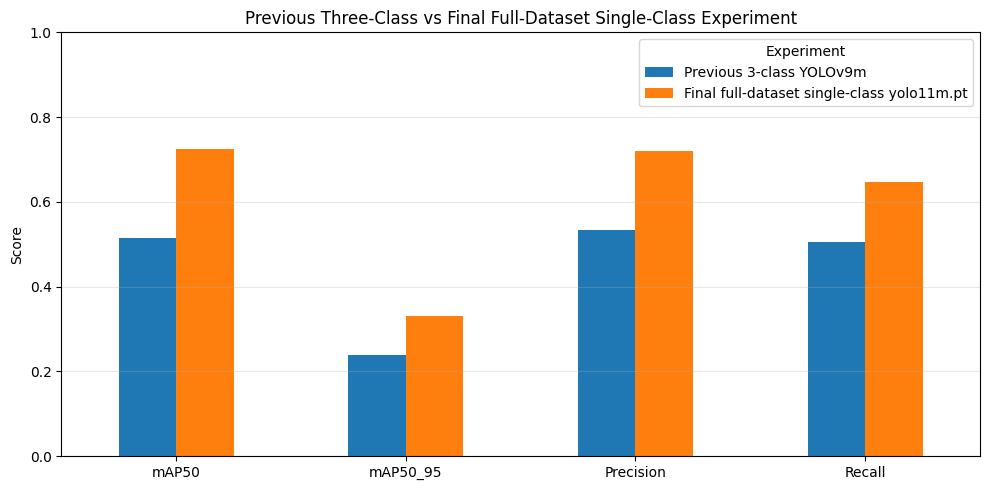

In [19]:
previous_baseline = {
    "Experiment": "Previous 3-class YOLOv9m",
    "mAP50": 0.5151,
    "mAP50_95": 0.2380,
    "Precision": 0.5341,
    "Recall": 0.5052,
}

current_test = metrics_summary[metrics_summary["split"] == "test"].iloc[0].to_dict()

current_result = {
    "Experiment": f"Final full-dataset single-class {MODEL_NAME}",
    "mAP50": current_test["mAP50"],
    "mAP50_95": current_test["mAP50_95"],
    "Precision": current_test["Precision"],
    "Recall": current_test["Recall"],
}

comparison_df = pd.DataFrame([previous_baseline, current_result])
display(comparison_df)

comparison_df.to_csv(DRIVE_OUTPUT_DIR / "previous_vs_single_class_comparison.csv", index=False)

ax = comparison_df.set_index("Experiment")[["mAP50", "mAP50_95", "Precision", "Recall"]].T.plot(kind="bar", figsize=(10, 5))
plt.title("Previous Three-Class vs Final Full-Dataset Single-Class Experiment")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(DRIVE_OUTPUT_DIR / "previous_vs_single_class_comparison.png", dpi=200)
plt.show()

## Final Result Summary

| Split | mAP50 | mAP50-95 | Precision | Recall |
|---|---:|---:|---:|---:|
| Validation | 0.7265 | 0.3337 | 0.7154 | 0.6680 |
| Test | 0.7238 | 0.3305 | 0.7193 | 0.6466 |

The final single-class experiment improved the previous three-class YOLOv9m baseline from mAP50 = 0.5151 to test mAP50 = 0.7238 while using the full dataset without excluding any lesion category.


## 15. Model Export Information

The best model path and final output directory are displayed below.


In [21]:
# Optional:
# best_model.export(format="onnx", imgsz=IMG_SIZE)
# best_model.export(format="torchscript", imgsz=IMG_SIZE)

print("Best model path:", best_model_path)
print("All final outputs are saved in:", DRIVE_OUTPUT_DIR)

Best model path: /content/drive/MyDrive/periapical_final_single_class_45ep/single_class_yolo11m_45ep_1024_20260522_213137/weights/best.pt
All final outputs are saved in: /content/drive/MyDrive/periapical_final_single_class_45ep
